In [2]:
from graph import create_graph

In [3]:
state_graph = create_graph()
graph_v0 = state_graph.compile()  # -- no memory

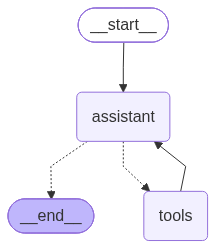

In [4]:
from IPython.display import Image, display
try:
    display(Image(graph_v0.get_graph().draw_mermaid_png()))
except Exception as ex:
    print("Couldnot render png")


## Lets talk to the graph

* A customer with some concern

In [ ]:
from langchain_core.messages import HumanMessage

turn_1 = graph_v0.invoke({
    "messages": [HumanMessage("I need a fix for skin detan")]
})

turn_1["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': 'To help brighten your complexion and address dullness or uneven skin tone caused by sun exposure, our **Radiance C Vitamin Serum** (priced at ₹699) is a great choice. It contains Vitamin C to help improve skin radiance and support a more even-looking skin tone. \n\nTo help me recommend the complete routine for you, could you please let me know what your current daily skincare routine looks like?', 'extras': {'signature': 'AY89a1/pXsALpBNvTAhJRJs2hhXSi3d5oeaF9N9GY8q2vcYvkTLg00Aalo2BAeT/Sg6ZrgvOZM0Q7gljGwakZodIu1kNKbJymKmNuHwBpIaOrmUS+xPStiIANHg='}}]


## Problem

* We are about to ask a follow up question
* The agent has no idea

In [6]:
turn_2 = graph_v0.invoke({
    "messages": [HumanMessage("Which product did you just recommend?")]
})
turn_2["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "Hello! I haven't recommended a product to you yet. Could you please tell me what skin or personal care concern you are looking to address today?", 'extras': {'signature': 'AY89a1+qRNuAti5FE25/0RhYw66nM4An4bzPlM+VzQOhxgGnKIDt4z6a/UIGQwiCcHB+N0kBeZOPkbs1GVhKMTQAGf+98eX+h2htLGP6fYGjwnj2dE327X71Bs0='}}]


In [7]:
print(f"Messages at the end of turn_1: ", len(turn_1["messages"]))
print(f"Messages at the end of turn_2: ", len(turn_2["messages"]))

Messages at the end of turn_1:  4
Messages at the end of turn_2:  2


In [8]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph_v1 = state_graph.compile(checkpointer=checkpointer)


In [9]:
cfg = {"configurable": {"thread_id": "some-conversation-id"}}

In [10]:
turn_1 = graph_v1.invoke({
    "messages": [HumanMessage("I need a fix for skin detan")]
}, cfg)

turn_1["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': 'To help address skin tanning and even out your complexion, our **Radiance C Vitamin Serum** (priced at ₹699) is a great choice as it is specifically formulated to improve the appearance of dull skin and uneven-looking skin tone. \n\nTo make sure this fits your routine perfectly, what is your primary skin type (e.g., oily, dry, normal, or sensitive)?', 'extras': {'signature': 'AY89a1/ObCSS+G0QccOmIDcUp79ZWAXNFiEh3SpZ75bWSDq126KSS8VFRtvNPbQcLJ1XZkyWiX8n0BS35xnhbxQ/VOUPBF1ZUaXShDQMcmbniZRQcEWZOr5euo0='}}]


In [11]:
turn_2 = graph_v1.invoke({
    "messages": [HumanMessage("Which product did you just recommend?")]
}, cfg)
turn_2["messages"][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "I recommended the **Radiance C Vitamin Serum** (Product ID: `LREAL-SKIN-003`, priced at ₹699). It is a brightening facial serum designed to improve the appearance of dull skin and support a more even-looking skin tone. \n\nTo help me check if it's the absolute best fit for you, could you let me know what your skin type is (e.g., normal, dry, oily, or combination)?", 'extras': {'signature': 'AY89a19Uxfu23Kj0Iyx/3DKq0LMJwTcHLffedJc5mzYIjeGfiXdzy1na5S1naqCL98zLN7Cf3MCC0aX42wsiX7ATkAx7666ND29gv9A9YVmfHnIZLqaaVbtWdDk='}}]


In [12]:
print(f"Messages at the end of turn_1: ", len(turn_1["messages"]))
print(f"Messages at the end of turn_2: ", len(turn_2["messages"]))

Messages at the end of turn_1:  4
Messages at the end of turn_2:  6


In [13]:
## Lets see whats inside a checkpoint

snapshot = graph_v1.get_state(cfg)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='I need a fix for skin detan', additional_kwargs={}, response_metadata={}, id='aca74eb3-b5ce-4d77-85ad-2a05b8d68145'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_all_products', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'call_682634': 'AY89a1+lzLldZNABwA6l7JD5Jp2cGBBAa6WORUObChCCFeC6+6ehEh1lLv7Y2XkwyFOO5FA5piEmfZ9AKs1E6pO/zYfs5FfmSOzF1v3lYOVCJIyISnBGWlbwOu0='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ffd0-a9a9-7c40-a776-8e354237285e-0', tool_calls=[{'name': 'get_all_products', 'args': {}, 'id': 'call_682634', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 502, 'output_tokens': 12, 'total_tokens': 514, 'input_token_details': {'cache_read': 0}}), ToolMessage(content="product_id | category | product_name | description | price_inr | siz

In [14]:
snapshot.config

{'configurable': {'thread_id': 'some-conversation-id',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bedae-7858-6243-8006-13b527b65d80'}}

In [19]:
for m in snapshot.values["messages"]:
    label = type(m).__name__
    if isinstance(m.content, str) and m.content != "" :
        body = m.content.replace("\n", " ")
    print(f"{label}  {body}")

HumanMessage  I need a fix for skin detan
AIMessage  I need a fix for skin detan
ToolMessage  product_id | category | product_name | description | price_inr | size | how_to_use | benefits | problems_it_solves | suitable_for LREAL-SKIN-001 | skin_care | HydraGlow Gentle Face Cleanser | A gentle, hydrating facial cleanser designed to remove dirt, excess oil, and daily impurities without leaving the skin feeling dry. | 349 | 100 ml | Wet your face with lukewarm water.; Apply a small amount of cleanser.; Massage gently in circular motions for 30 to 60 seconds.; Rinse thoroughly and pat dry. | Cleanses the skin; Helps maintain skin hydration; Removes excess oil; Leaves skin feeling fresh | Daily facial dirt; Excess oil; Skin feeling tight after cleansing; Mild dryness caused by harsh cleansers | Normal skin; Dry skin; Combination skin LREAL-SKIN-002 | skin_care | ClearBalance Oil Control Serum | A lightweight facial serum formulated for oily and combination skin to help manage excess oil an

In [21]:
## Adding multiple customers

def chat(thread_id="new-session"):
    cfg = {"configurable": {"thread_id": thread_id}}
    print(f"Chatting on thread: {thread_id}")
    while True:
        text = input("You: ")
        if text.strip().lower() in {'exit', 'quit', ''}:
            print("\n ended")
            break
        out = graph_v1.invoke({"messages": [HumanMessage(text)]}, cfg)
        print("Advisor: ", out["messages"][-1].content, "\n" )

In [22]:
# customer_1
chat("customer-1")

Chatting on thread: customer-1
Advisor:  [{'type': 'text', 'text': 'To help address your skin detan concern and brighten your complexion, I would recommend our **Radiance C Vitamin Serum** (LREAL-SKIN-003). It is specially designed to improve the appearance of dull skin and uneven-looking skin tone. \n\nTo help us get this order placed for you, could you please share your full name?', 'extras': {'signature': 'AY89a19RhsY0EWb0lMQnO71RkZWUGkHkOXgXNaR2nDrmwTOuch/y5uQQ5Dzfd2JHA+v9XMugqb2X7NGVOpTTNLL1cYxk6Pima2cjQcwY3n6x7MOZ7ZpnWzN9XqU='}}] 

Advisor:  [{'type': 'text', 'text': 'The Radiance C Vitamin Serum is priced at ₹699 for a 30 ml bottle. \n\nWhenever you are ready to proceed, could you please share your full name so we can get your details noted down?', 'extras': {'signature': 'AY89a1/PrlrkQIH77zaHFTfsHhjvJPqcimoALCdzHyALYSspokNg6CAzh7RXVizU4FzspZtgNkS0ZFGwcDT1P0Kk6WXAkkg8wZvLfqmQX32FuJHjeUsJNoJnY6g='}}] 

Advisor:  [{'type': 'text', 'text': 'Thank you, Khaja! \n\nTo complete your or

In [23]:
chat("customer-2")

Chatting on thread: customer-2
Advisor:  [{'type': 'text', 'text': 'We have a couple of great options specifically designed for oily skin:\n\n1. **ClearBalance Oil Control Serum** (₹599) – A lightweight facial serum formulated to manage excess oil and improve the appearance of pores.\n2. **HydraGlow Gentle Face Cleanser** (₹349) – A gentle cleanser that removes excess oil and daily impurities without stripping the skin of its moisture.\n\nWould you like to go ahead with the **ClearBalance Oil Control Serum**?', 'extras': {'signature': 'AY89a19IafePpT6kHwuJVLYvGCZbk2Q/Penb+C7/BN4jBvx27WzcD9t4IQbsLrqUqT9I+MrFV4Pgwwv5ODQS5DOjsCMj8iaR6M8nHB1KSOo5CqMF7rXlAlmdOUA='}}] 

Advisor:  [{'type': 'text', 'text': 'The **HydraGlow Gentle Face Cleanser** is priced at **₹349** for a **100 ml** bottle. \n\nHere are the key details about it:\n* **Benefits:** It effectively cleanses the skin, removes excess oil, and helps maintain skin hydration so your face feels fresh without feeling tight or dry.\n* **

In [24]:
chat("customer-2")

Chatting on thread: customer-2
Advisor:  [{'type': 'text', 'text': 'You were trying to buy the **HydraGlow Gentle Face Cleanser** (priced at ₹349 for 100 ml). \n\nShall we go ahead and complete your order? If so, could you please share your full name?', 'extras': {'signature': 'AY89a1+bPhtIvMRp5W4Gb5h2u/6JQ/h8UzLE5B1UWYjOC+FElbbPQXOOjzey1YLpQ1Lkk4RBRaGybkkFtYJ/MOcoqvk66nz18nQ/JU2hTTaJ9BXHKOgnupgyBJQ='}}] 

Advisor:  [{'type': 'text', 'text': 'Wonderful! Could you please share your full name to get started?', 'extras': {'signature': 'AY89a19OYJ9rWvHbDBZQ1V2koKoy/R30LwSsRLPncjgSUQv37LLmpJkeYOh/lF4HOoMxNSaPjT7Io4w78svKJVJtyH4zNl010zu2rqlhzPFKINVWHpPcU3Nw8Og='}}] 


 ended


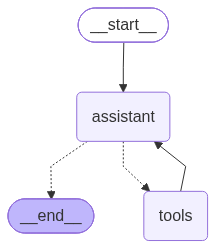

In [25]:
from graph import create_graph
graph_v1_with_summary = create_graph().compile()
from IPython.display import Image, display
try:
    display(Image(graph_v0.get_graph().draw_mermaid_png()))
except Exception as ex:
    print("Couldnot render png")
